In [41]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import kagglehub
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## 1. Download dataset and EDA

In [2]:
path = kagglehub.dataset_download("redwankarimsony/heart-disease-data")

print("Path to dataset files:", path)

Path to dataset files: /home/asus/.cache/kagglehub/datasets/redwankarimsony/heart-disease-data/versions/6


In [3]:
os.listdir(path)

['heart_disease_uci.csv']

In [4]:
df = pd.read_csv(f"{path}/heart_disease_uci.csv")

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [5]:
df.shape

(920, 16)

In [6]:
# Remove useless columns

df = df.drop(["dataset", "id"], axis=1)

In [7]:
# Transform the target into binary
# 0 -> no hearth disease
# 1 -> hearth disease

df["target"] = df["num"].apply(lambda x: 0 if x == 0 else 1)
df = df.drop("num", axis=1)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   cp        920 non-null    object 
 3   trestbps  861 non-null    float64
 4   chol      890 non-null    float64
 5   fbs       830 non-null    object 
 6   restecg   918 non-null    object 
 7   thalch    865 non-null    float64
 8   exang     865 non-null    object 
 9   oldpeak   858 non-null    float64
 10  slope     611 non-null    object 
 11  ca        309 non-null    float64
 12  thal      434 non-null    object 
 13  target    920 non-null    int64  
dtypes: float64(5), int64(2), object(7)
memory usage: 100.8+ KB


In [9]:
df.isnull().sum().sort_values(ascending=False)

ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
thalch       55
exang        55
chol         30
restecg       2
cp            0
sex           0
age           0
target        0
dtype: int64

Columns having too many missing values are: "slope", "thal" and "ca". I simply remove these columns.

For the others, I use the median/mode to fill null values.

In [10]:
# Too many missing values -> remove columns

df = df.drop(["ca", "thal", "slope"], axis=1)

In [11]:
# Not too many missing values -> fill with median (if numerical), and mode (if categorical)

df = df.fillna(df.median(numeric_only=True))
df = df.fillna(df.mode().iloc[0])

/tmp/ipykernel_11550/3878729759.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(df.mode().iloc[0])


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   cp        920 non-null    object 
 3   trestbps  920 non-null    float64
 4   chol      920 non-null    float64
 5   fbs       920 non-null    bool   
 6   restecg   920 non-null    object 
 7   thalch    920 non-null    float64
 8   exang     920 non-null    bool   
 9   oldpeak   920 non-null    float64
 10  target    920 non-null    int64  
dtypes: bool(2), float64(4), int64(2), object(3)
memory usage: 66.6+ KB


## 2. Preparing data for the model

In [13]:
# OHE for categorical features

df = pd.get_dummies(df, drop_first=True)

In [16]:
# Train test split

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
print(X_train.shape)
print(X_test.shape)

(736, 13)
(184, 13)


In [19]:
# Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Modeling: K-NN

In [22]:
# Cross validation with different K values 

k_values = range(1, 31)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())

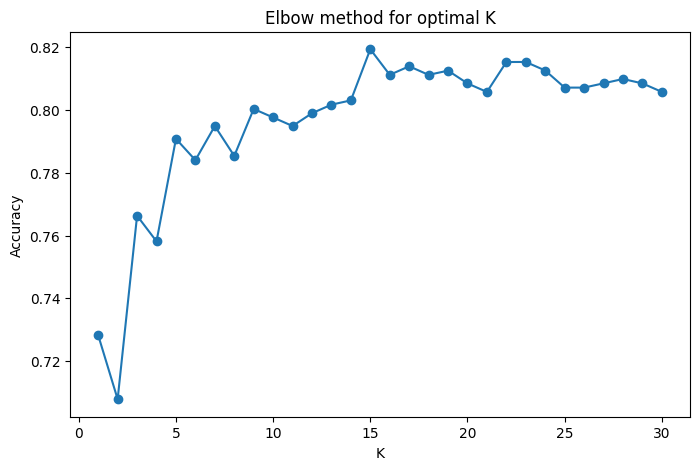

In [24]:
# Elbow method

plt.figure(figsize=(8,5))
plt.plot(k_values, cv_scores, marker="o")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("Elbow method for optimal K")
plt.show()

In [25]:
# Best K?

best_k = k_values[cv_scores.index(max(cv_scores))]
print("Best K: ", best_k)

Best K:  15


In [26]:
# Train the best model with K=15

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

In [28]:
# Accuracy

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

Accuracy:  0.8152173913043478


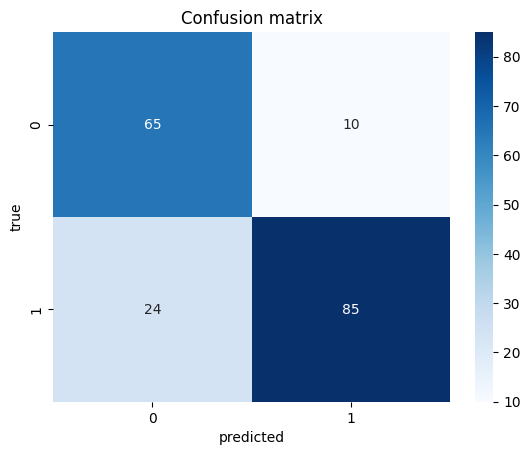

In [30]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("predicted")
plt.ylabel("true")
plt.title("Confusion matrix")
plt.show()

In [31]:
# Classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.87      0.79        75
           1       0.89      0.78      0.83       109

    accuracy                           0.82       184
   macro avg       0.81      0.82      0.81       184
weighted avg       0.83      0.82      0.82       184



In [32]:
# ROC curve

y_prob = knn.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_pred)

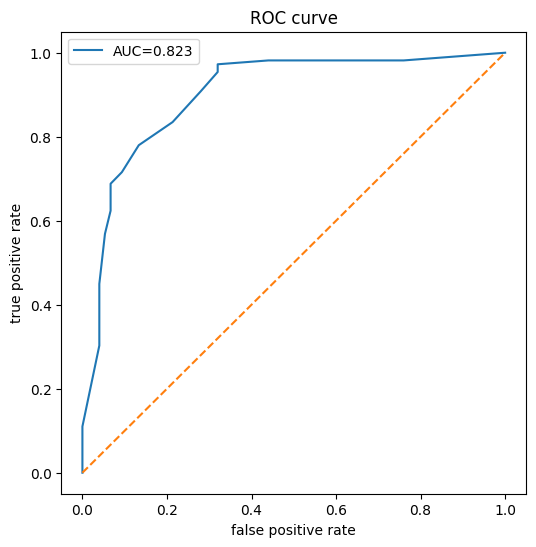

In [33]:
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("ROC curve")
plt.legend()
plt.show()

The model achieves an accuracy of 81.5% on the test set. The performances are balanced across classes, with F1 score of 0.79 for class 0 and 0.83 for class 1. Precision for detecting hearth disease is high (0.89), while recall (0.78) indicated that some positive cases are misclassified. 

## 4. Decision boundary visualization using PCA

In [35]:
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [36]:
knn_pca = KNeighborsClassifier(n_neighbors=best_k)

knn_pca.fit(X_train_pca, y_train)

KNeighborsClassifier(n_neighbors=15)

In [37]:
# Create grid

h = 0.02

x_min, x_max = X_train_pca[:,0].min()-1, X_train_pca[:,0].max()+1
y_min, y_max = X_train_pca[:,1].min()-1, X_train_pca[:,1].max()+1

xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

In [38]:
Z = knn_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

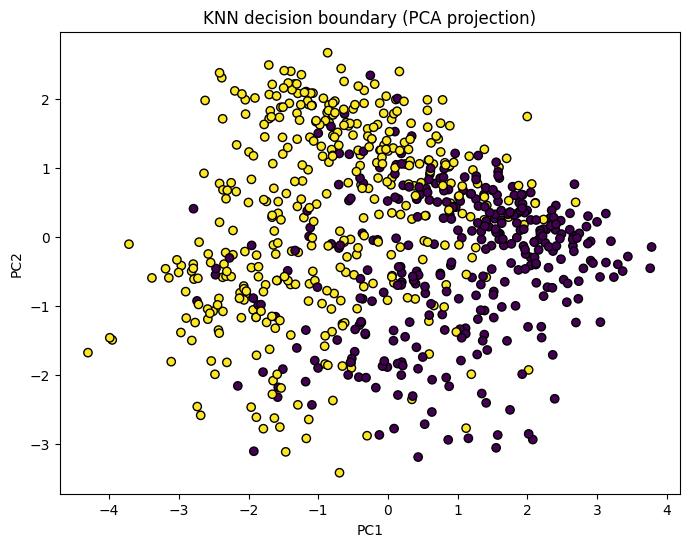

In [39]:
# Plot

plt.figure(figsize=(8,6))

plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, edgecolor="k")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KNN decision boundary (PCA projection)")

plt.show()

## 5. Model comparison

In [42]:
# Logistic regression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

In [43]:
# Decision tree

decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train_scaled, y_train)

y_pred_dt = decision_tree.predict(X_test_scaled)

In [44]:
# Random forest

random_forest = RandomForestClassifier(random_state=42)
random_forest.fit(X_train_scaled, y_train)

y_pred_rf = random_forest.predict(X_test_scaled)

In [45]:
# Accuracies

acc_knn = accuracy_score(y_test, y_pred)
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("KNN:", acc_knn)
print("Logistic Regression:", acc_lr)
print("Decision Tree:", acc_dt)
print("Random Forest:", acc_rf)

KNN: 0.8152173913043478
Logistic Regression: 0.7989130434782609
Decision Tree: 0.7228260869565217
Random Forest: 0.8478260869565217


In [48]:
# Cross validation to compare models

models = {
    "KNN": KNeighborsClassifier(n_neighbors=best_k),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    cv_results[name] = scores.mean()

cv_results

{'KNN': np.float64(0.8193050193050192),
 'Logistic Regression': np.float64(0.8016547159404303),
 'Decision Tree': np.float64(0.7255561684133113),
 'Random Forest': np.float64(0.7975914690200405)}

In [49]:
results = pd.DataFrame(list(cv_results.items()), columns=["Model", "CV Accuracy"])
results

,Model,CV Accuracy
0,KNN,0.819305
1,Logistic Regression,0.801655
2,Decision Tree,0.725556
3,Random Forest,0.797591
